In [1]:
library(Matrix)
library(xgboost)
library(ggplot2)
library(lattice)
library(caret)
library(dplyr)
library(tictoc)
library(recipes)


Attachement du package : ‘dplyr’


L'objet suivant est masqué depuis ‘package:xgboost’:

    slice


Les objets suivants sont masqués depuis ‘package:stats’:

    filter, lag


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, setdiff, setequal, union



Attachement du package : ‘recipes’


L'objet suivant est masqué depuis ‘package:Matrix’:

    update


L'objet suivant est masqué depuis ‘package:stats’:

    step




In [2]:
data <- read.csv("data_target_encoding.csv",stringsAsFactors = T)
test <- read.csv("test_target_encoding.csv",stringsAsFactors = T)

In [4]:
options(repr.matrix.max.cols=100)
data[1:3,]

,geo_level_1_mean_damage,geo_level_1_sd_damage,geo_level_2_mean_damage,geo_level_2_sd_damage,geo_level_3_mean_damage,geo_level_3_sd_damage,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,2.020477,0.4558226,1.984293,0.2987067,1.971429,0.1690309,1,25,5,2,t,r,n,f,j,s,d,0,1,0,0,0,0,0,0,0,0,0,v,0,0,0,0,0,0,0,0,0,0,0,2
2,2.794480,0.4352255,2.977444,0.1490457,3.000000,0.0000000,2,0,13,7,t,r,n,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,3
3,2.794480,0.4352255,2.984772,0.1227723,3.000000,0.0000000,2,5,12,6,o,r,q,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,3


In [6]:
X <- sparse.model.matrix(damage_grade ~ .,data = data)[,-1]
y <- as.numeric(data[,c("damage_grade")]-1)

In [27]:
options(repr.matrix.max.cols=100)
X[1:3,]

  [[ suppressing 62 column names ‘geo_level_1_mean_damage’, ‘geo_level_1_sd_damage’, ‘geo_level_2_mean_damage’ ... ]]



3 x 62 sparse Matrix of class "dgCMatrix"
                                                                              
1 2.020477 0.4558226 1.984293 0.2987067 1.971429 0.1690309 1 25  5 2 . 1 . 1 .
2 2.794480 0.4352255 2.977444 0.1490457 3.000000 .         2  . 13 7 . 1 . 1 .
3 2.794480 0.4352255 2.984772 0.1227723 3.000000 .         2  5 12 6 1 . . 1 .
                                                                               
1 . . . . . . . . . . . 1 . . 1 . . . . . . . . 1 . . . . . . . . . . 1 . . . .
2 . . . . . . . 1 . . . 1 . . 1 . . . . . . . . 1 . . . . . . . . . . 1 . 1 . .
3 . 1 . . . . . 1 . . . 1 . . 1 . . . . . . . . 1 . . . . . . . . . . 1 . 1 . .
                 
1 . . . . . . . .
2 . . . . . . . .
3 . . . . . . . .

In [14]:
idx_damage_grade_1 <- which(data$damage_grade == 1)
length(idx_damage_grade_1)

[1] 25124

xgboost 5cv subsample

In [44]:
accuracy_vec

[1] 0.3389718 0.3365174 0.3354561 0.3347927 0.3314756

In [16]:
k = 5
accuracy_vec <- array(0,k)


idx_damage_grade_1 <- which(data$damage_grade == 1)
n_sub <- length(idx_damage_grade_1)

idx_damage_grade_2 <- sample(which(data$damage_grade == 2),n_sub)
idx_damage_grade_3 <- sample(which(data$damage_grade == 3),n_sub)

X.sub <- rbind(X[idx_damage_grade_1,],X[idx_damage_grade_2,],X[idx_damage_grade_3,])
y.sub <- rbind(y[idx_damage_grade_1],y[idx_damage_grade_2],y[idx_damage_grade_3])

spam_idx <- sample(1:nrow(X.sub))
max <- ceiling(nrow(X.sub)/k)
splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 

tic()
pb2 <- txtProgressBar(min = 1, max = k, style = 3)
for (i in 1:k){
    X.sub.test <- X.sub[splits[[i]],]
    y.sub.test <- y.sub[splits[[i]]]
    X.sub.train <- X.sub[-splits[[i]],]
    y.sub.train <- y.sub[-splits[[i]]]
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )

    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model <- caret::train(
    x = X.sub.train,
    y = as.factor(y.sub.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model, X.sub.test)
    ll <- length(y.sub.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.sub.test[j]+1)] <- cfm[pred[j],(y.sub.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
}

print(mean(accuracy_vec))
toc()

  |                                                                      |   0%[1] 0.3389718
  |==================                                                    |  25%[1] 0.3365174
  |===================================                                   |  50%[1] 0.3354561
  |====================================================                  |  75%[1] 0.3347927
  |======================================================================| 100%[1] 0.3314756
[1] 0.3354427
156.191 sec elapsed


Feature selection ussing mRMR

On importe le dataset avec les one-hot encoding pour proceder decus le mRMR

In [17]:
dataNN <- read.csv("data_target_encoding_NN.csv",stringsAsFactors = T)

In [18]:
n<-ncol(dataNN)
targets<-which(grepl('damage_grade',colnames(dataNN)))
correlation<-abs(cor(dataNN[,-targets,drop=F],dataNN[,targets,drop=F]))
selected<-c()
candidates<-1:n

    #mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
    for (j in 1:n) {
        redundancy_score<-numeric(length(candidates))
        
        if (length(selected)>0) {
            # Compute the correlation between the selected variables and the candidates on the training set
            cor_selected_candidates<-cor(dataNN[,selected,drop=F],dataNN[,candidates,drop=F])
            # Compute the mean correlation for each candidate variable, across the selected variables
            redundancy_score<-apply(cor_selected_candidates,2,mean)
        }
        
        # mRMR: minimum Redundancy Maximum Relevancy
        mRMR_score<-correlation[candidates]-redundancy_score
        
        # Select the candidate variable that maximises the mRMR score
        selected_current<-candidates[which.max(mRMR_score)]
        selected<-c(selected,selected_current)
        
        # Remove the selected variables from the candidates
        candidates<-setdiff(candidates,selected_current)
    }
    
    rankingNN <- selected

In [19]:
rankingNN
colnames(dataNN)[rankingNN]

[1]  5  2 38  3 46 12 16  1 43 37  4 51 50 44 42 40 39 20 41  8 19 49  6  7  9
[26] 17 56 24 67 25 45 18 66 13 14 11 22 69 53 70 59 48 60 26 58 65 57 21 68 55
[51] 32 36 34 35 52 63 23 10 28 27 64 30 29 61 33 31 62 15 47 54

[1] "geo_level_3_mean_damage"               
 [2] "geo_level_1_sd_damage"                 
 [3] "foundation_type_i"                     
 [4] "geo_level_2_mean_damage"               
 [5] "ground_floor_type_m"                   
 [6] "has_superstructure_mud_mortar_stone"   
 [7] "has_superstructure_cement_mortar_brick"
 [8] "geo_level_1_mean_damage"               
 [9] "roof_type_q"                           
[10] "foundation_type_h"                     
[11] "geo_level_2_sd_damage"                 
[12] "other_floor_type_q"                    
[13] "other_floor_type_j"                    
[14] "roof_type_x"                           
[15] "roof_type_n"                           
[16] "foundation_type_u"                     
[17] "foundation_type_r"                     
[18] "has_superstructure_rc_engineered"      
[19] "foundation_type_w"                     
[20] "age"                                   
[21] "has_superstructure_rc_non_engineered"  
[22] "ground_floor_type_z"                   
[23] "geo_level_3_sd_damage"                 
[24] "count_floors_pre_eq"                   
[25] "area_percentage"                       
[26] "has_superstructure_timber"             
[27] "position_s"                            
[28] "has_secondary_use_hotel"               
[29] "plan_configuration_u"                  
[30] "has_secondary_use_rental"              
[31] "ground_floor_type_f"                   
[32] "has_superstructure_bamboo"             
[33] "plan_configuration_s"                  
[34] "has_superstructure_stone_flag"         
[35] "has_superstructure_cement_mortar_stone"
[36] "has_superstructure_adobe_mud"          
[37] "count_families"                        
[38] "legal_ownership_status_r"              
[39] "other_floor_type_x"                    
[40] "legal_ownership_status_v"              
[41] "plan_configuration_c"                  
[42] "ground_floor_type_x"                   
[43] "plan_configuration_d"                  
[44] "has_secondary_use_institution"         
[45] "plan_configuration_a"                  
[46] "plan_configuration_q"                  
[47] "position_t"                            
[48] "has_superstructure_other"              
[49] "legal_ownership_status_a"              
[50] "position_o"                            
[51] "has_secondary_use_other"               
[52] "land_surface_condition_t"              
[53] "land_surface_condition_n"              
[54] "land_surface_condition_o"              
[55] "other_floor_type_s"                    
[56] "plan_configuration_n"                  
[57] "has_secondary_use_agriculture"         
[58] "height_percentage"                     
[59] "has_secondary_use_industry"            
[60] "has_secondary_use_school"              
[61] "plan_configuration_o"                  
[62] "has_secondary_use_gov_office"          
[63] "has_secondary_use_health_post"         
[64] "plan_configuration_f"                  
[65] "damage_grade"                          
[66] "has_secondary_use_use_police"          
[67] "plan_configuration_m"                  
[68] "has_superstructure_mud_mortar_brick"   
[69] "ground_floor_type_v"                   
[70] "position_j"

In [20]:
length(rankingNN)

[1] 70

In [22]:
rankingNN[1:2]

[1] 5 2

In [31]:
length(seq(2,length(rankingNN),2))

[1] 35

In [24]:
X[1:3,rankingNN[1:2]]

3 x 2 sparse Matrix of class "dgCMatrix"
  geo_level_3_mean_damage geo_level_1_sd_damage
1                1.971429             0.4558226
2                3.000000             0.4352255
3                3.000000             0.4352255

In [33]:
A <-matrix(0, nrow = length(seq(2,length(rankingNN),2)), ncol = 5)

In [41]:
A

0,0,0,0,0
0,0,0,0,0
0,0,0,0,0
0,0,0,0,0
0,0,0,0,0
0,0,0,0,0
0,0,0,0,0
0,0,0,0,0
0,0,0,0,0
0,0,0,0,0
0,0,0,0,0


In [36]:
seq(2,length(rankingNN),2)/2

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30 31 32 33 34 35

In [43]:
for (j in seq(2,length(rankingNN),2)){print(A[j/2,])}

[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0
[1] 0 0 0 0 0


Feature selection 

In [45]:
k = 5
accuracy_matrix <- matrix(0, nrow = length(seq(2,length(rankingNN),2)), ncol = k)

tic()
pb1 <- txtProgressBar(min = 1, max = length(seq(2,length(rankingNN),2)), style = 3)
for (l in seq(2,length(rankingNN),2)){
    
    X.f  <- X[,rankingNN[1:l]]
    
    spam_idx <- sample(1:nrow(X.f))
    max <- ceiling(nrow(X.f)/k)
    splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 
    
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
    for (i in 1:k){
        X.f.test <- X.f[splits[[i]],]
        y.test <- y[splits[[i]]]
        X.f.train <- X.f[-splits[[i]],]
        y.train <- y[-splits[[i]]]
    
        grid_default <- expand.grid(
        nrounds = 100,
        max_depth = 6,
        eta = 0.3,
        gamma = 0,
        colsample_bytree = 1,
        min_child_weight = 1,
        subsample = 1
        )
        
        train_control <- caret::trainControl(
        method = "none",
        verboseIter = FALSE, # no training log
        allowParallel = TRUE, # FALSE for reproducible results 
        summaryFunction = multiClassSummary
        )

        xgb_model <- caret::train(
        x = X.f.train,
        y = as.factor(y.train),
        trControl = train_control,
        tuneGrid = grid_default,
        method = "xgbTree",
        verbose = TRUE
        )

        pred <- predict(xgb_model, X.f.test)
        ll <- length(y.test)
        cfm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
        TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
        FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
        FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_matrix[l/2,i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
    }
    setTxtProgressBar(pb1, l/2)
    print(mean(accuracy_matrix[l/2,]))
    toc()
}

  |                                                                      |   0%[1] 0.729303
  |==================                                                    |  25%[1] 0.7289001
  |===================================                                   |  50%[1] 0.7279791
  |====================================================                  |  75%[1] 0.7325646
  |======================================================================| 100%[1] 0.7280926
  |                                                                      |   0%[1] 0.7293679
48.044 sec elapsed
  |                                                                      |   0%[1] 0.7257727
  |==================                                                    |  25%[1] 0.7291687
  |===================================                                   |  50%[1] 0.733639
  |====================================================                  |  75%[1] 0.7304158
  |==================================================

ERROR: Error in intI(j, n = x@Dim[2], dn[[2]], give.dn = FALSE): indice plus grand que la valeur maximale 62


In [46]:
accuracy_matrix

0.7293030,0.7289001,0.7279791,0.7325646,0.7280926
0.7257727,0.7291687,0.7336390,0.7304158,0.7312969
0.7354233,0.7390303,0.7365170,0.7325838,0.7353455
0.7340036,0.7396059,0.7370350,0.7363443,0.7362665
0.7433856,0.7399705,0.7411216,0.7391455,0.7397202
0.7441722,0.7415821,0.7413135,0.7397210,0.7422914
0.7423495,0.7432129,0.7406995,0.7432129,0.7423106
0.7432897,0.7416396,0.7425990,0.7493717,0.7391638
0.7473571,0.7502350,0.7487001,0.7468007,0.7474528
0.7510600,0.7517124,0.7535542,0.7550699,0.7529789
0.7480670,0.7541874,0.7554345,0.7542066,0.7517317


Problème d'encodage on recomence 

je vais one-hot le data_target_encoding puis luit appliquer mRMR déçu 

In [47]:
data[1:3,]

,geo_level_1_mean_damage,geo_level_1_sd_damage,geo_level_2_mean_damage,geo_level_2_sd_damage,geo_level_3_mean_damage,geo_level_3_sd_damage,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,2.020477,0.4558226,1.984293,0.2987067,1.971429,0.1690309,1,25,5,2,t,r,n,f,j,s,d,0,1,0,0,0,0,0,0,0,0,0,v,0,0,0,0,0,0,0,0,0,0,0,2
2,2.794480,0.4352255,2.977444,0.1490457,3.000000,0.0000000,2,0,13,7,t,r,n,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,3
3,2.794480,0.4352255,2.984772,0.1227723,3.000000,0.0000000,2,5,12,6,o,r,q,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,3


In [3]:
dummy_data <- dummyVars(" ~ .", data=data)  
data.dummy <- data.frame(predict(dummy_data, newdata = data)) 

In [59]:
options(repr.matrix.max.cols=100)
data.dummy[1:3,]

,geo_level_1_mean_damage,geo_level_1_sd_damage,geo_level_2_mean_damage,geo_level_2_sd_damage,geo_level_3_mean_damage,geo_level_3_sd_damage,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition.n,land_surface_condition.o,land_surface_condition.t,foundation_type.h,foundation_type.i,foundation_type.r,foundation_type.u,foundation_type.w,roof_type.n,roof_type.q,roof_type.x,ground_floor_type.f,ground_floor_type.m,ground_floor_type.v,ground_floor_type.x,ground_floor_type.z,other_floor_type.j,other_floor_type.q,other_floor_type.s,other_floor_type.x,position.j,position.o,position.s,position.t,plan_configuration.a,plan_configuration.c,plan_configuration.d,plan_configuration.f,plan_configuration.m,plan_configuration.n,plan_configuration.o,plan_configuration.q,plan_configuration.s,plan_configuration.u,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status.a,legal_ownership_status.r,legal_ownership_status.v,legal_ownership_status.w,count_families,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2.020477,0.4558226,1.984293,0.2987067,1.971429,0.1690309,1,25,5,2,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2
2,2.794480,0.4352255,2.977444,0.1490457,3.000000,0.0000000,2,0,13,7,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,3
3,2.794480,0.4352255,2.984772,0.1227723,3.000000,0.0000000,2,5,12,6,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,3


In [4]:
X.dummy <- sparse.model.matrix(damage_grade ~ .,data = data.dummy)[,-1]
y.dummy <- as.numeric(data.dummy[,c("damage_grade")]-1)

on regarde si sa change quelle que chose d'avoir one-hot avant 

In [64]:
k = 5
accuracy_vec <- array(0,k)

spam_idx <- sample(1:nrow(X))
max <- ceiling(nrow(X)/k)
splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 

tic()
pb2 <- txtProgressBar(min = 1, max = k, style = 3)
for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <- y[splits[[i]]]
    X.train <- X[-splits[[i]],]
    y.train <- y[-splits[[i]]]
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )

    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model <- caret::train(
    x = X.train,
    y = as.factor(y.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model, X.test)
    ll <- length(y.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.test[j]+1)] <- cfm[pred[j],(y.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
}

print(mean(accuracy_vec))
toc()

  |                                                                      |   0%[1] 0.7591182
  |==================                                                    |  25%[1] 0.7612479
  |===================================                                   |  50%[1] 0.7638764
  |====================================================                  |  75%[1] 0.7617083
  |======================================================================| 100%[1] 0.7621505
[1] 0.7616203
556.399 sec elapsed


In [65]:
ls()

[1] "A"                       "accuracy_matrix"        
 [3] "accuracy_vec"            "candidates"             
 [5] "cfm"                     "cor_selected_candidates"
 [7] "correlation"             "data"                   
 [9] "data_dummy"              "data.dummy"             
[11] "data.dummy.caret"        "data.dummy.recipe"      
[13] "dataNN"                  "datasub_1idx"           
[15] "dummy_data"              "FN"                     
[17] "FP"                      "grid_default"           
[19] "i"                       "idx_damage_grade_1"     
[21] "idx_damage_grade_2"      "idx_damage_grade_3"     
[23] "j"                       "k"                      
[25] "l"                       "ll"                     
[27] "max"                     "mRMR_score"             
[29] "n"                       "n_sub"                  
[31] "P_micro"                 "pb1"                    
[33] "pb2"                     "pred"                   
[35] "R_micro"                 "ranking.dummy"          
[37] "rankingNN"               "redundancy_score"       
[39] "selected"                "selected_current"       
[41] "spam_idx"                "splits"                 
[43] "targets"                 "test"                   
[45] "TP"                      "train_control"          
[47] "X"                       "X.dummy"                
[49] "X.dummy.test"            "X.dummy.train"          
[51] "X.f"                     "X.f.test"               
[53] "X.f.train"               "X.sub"                  
[55] "X.sub.test"              "X.sub.train"            
[57] "X.test"                  "X.train"                
[59] "xgb_model"               "y"                      
[61] "y.dummy"                 "y.dummy.test"           
[63] "y.dummy.train"           "y.sub"                  
[65] "y.sub.test"              "y.sub.train"            
[67] "y.test"                  "y.train"

In [61]:
k = 5
accuracy_vec <- array(0,k)

spam_idx <- sample(1:nrow(X.dummy))
max <- ceiling(nrow(X.dummy)/k)
splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 

tic()
pb2 <- txtProgressBar(min = 1, max = k, style = 3)
for (i in 1:k){
    X.dummy.test <- X.dummy[splits[[i]],]
    y.dummy.test <- y.dummy[splits[[i]]]
    X.dummy.train <- X.dummy[-splits[[i]],]
    y.dummy.train <- y.dummy[-splits[[i]]]
    
    grid_default <- expand.grid(
    nrounds = 100,
    max_depth = 6,
    eta = 0.3,
    gamma = 0,
    colsample_bytree = 1,
    min_child_weight = 1,
    subsample = 1
    )

    train_control <- caret::trainControl(
    method = "none",
    verboseIter = FALSE, # no training log
    allowParallel = TRUE, # FALSE for reproducible results 
    summaryFunction = multiClassSummary
    )

    xgb_model <- caret::train(
    x = X.dummy.train,
    y = as.factor(y.dummy.train),
    trControl = train_control,
    tuneGrid = grid_default,
    method = "xgbTree",
    verbose = TRUE
    )

    pred <- predict(xgb_model, X.dummy.test)
    ll <- length(y.dummy.test)
    cfm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:ll){cfm[pred[j],(y.dummy.test[j]+1)] <- cfm[pred[j],(y.dummy.test[j]+1)]+1}
    TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
    FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
    FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
    setTxtProgressBar(pb2, i)
    print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
}

print(mean(accuracy_vec))
toc()

  |                                                                      |   0%[1] 0.7604229
  |==================                                                    |  25%[1] 0.7641642
  |===================================                                   |  50%[1] 0.7596938
  |====================================================                  |  75%[1] 0.7623798
  |======================================================================| 100%[1] 0.7606155
[1] 0.7614552
625.842 sec elapsed


In [5]:
set.seed(2)

n<-ncol(data.dummy)
targets<-which(grepl('damage_grade',colnames(data.dummy)))
correlation<-abs(cor(data.dummy[,-targets,drop=F],data.dummy[,targets,drop=F]))
selected<-c()
candidates<-1:n

    #mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
    for (j in 1:n) {
        redundancy_score<-numeric(length(candidates))
        
        if (length(selected)>0) {
            # Compute the correlation between the selected variables and the candidates on the training set
            cor_selected_candidates<-cor(data.dummy[,selected,drop=F],data.dummy[,candidates,drop=F])
            # Compute the mean correlation for each candidate variable, across the selected variables
            redundancy_score<-apply(cor_selected_candidates,2,mean)
        }
        
        # mRMR: minimum Redundancy Maximum Relevancy
        mRMR_score<-correlation[candidates]-redundancy_score
        
        # Select the candidate variable that maximises the mRMR score
        selected_current<-candidates[which.max(mRMR_score)]
        selected<-c(selected,selected_current)
        
        # Remove the selected variables from the candidates
        candidates<-setdiff(candidates,selected_current)
    }
    
    ranking.dummy <- selected

In [80]:
typeof(data.dummy)

[1] "list"

In [81]:
data.dummy[1:3,]

,geo_level_1_mean_damage,geo_level_1_sd_damage,geo_level_2_mean_damage,geo_level_2_sd_damage,geo_level_3_mean_damage,geo_level_3_sd_damage,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition.n,land_surface_condition.o,land_surface_condition.t,foundation_type.h,foundation_type.i,foundation_type.r,foundation_type.u,foundation_type.w,roof_type.n,roof_type.q,roof_type.x,ground_floor_type.f,ground_floor_type.m,ground_floor_type.v,ground_floor_type.x,ground_floor_type.z,other_floor_type.j,other_floor_type.q,other_floor_type.s,other_floor_type.x,position.j,position.o,position.s,position.t,plan_configuration.a,plan_configuration.c,plan_configuration.d,plan_configuration.f,plan_configuration.m,plan_configuration.n,plan_configuration.o,plan_configuration.q,plan_configuration.s,plan_configuration.u,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status.a,legal_ownership_status.r,legal_ownership_status.v,legal_ownership_status.w,count_families,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2.020477,0.4558226,1.984293,0.2987067,1.971429,0.1690309,1,25,5,2,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2
2,2.794480,0.4352255,2.977444,0.1490457,3.000000,0.0000000,2,0,13,7,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,3
3,2.794480,0.4352255,2.984772,0.1227723,3.000000,0.0000000,2,5,12,6,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,3


In [6]:
ranking.dummy
colnames(data.dummy)[ranking.dummy]

[1]  5 24 22  3  2 50 16  1 18 21 46 15  4 28 27 29 17 19 54 20 53  6  7 51 56
[26]  9 30 58 52 62 47 63 33 45 34 44 37 60 48 59  8 55 64 35 25 36 26 23 42 31
[51] 61 12 13 11 41 14 70 43 10 66 65 68 67 57 39 40 69 38 49 32

[1] "geo_level_3_mean_damage"               
 [2] "ground_floor_type.v"                   
 [3] "ground_floor_type.f"                   
 [4] "geo_level_2_mean_damage"               
 [5] "geo_level_1_sd_damage"                 
 [6] "has_superstructure_cement_mortar_brick"
 [7] "foundation_type.r"                     
 [8] "geo_level_1_mean_damage"               
 [9] "foundation_type.w"                     
[10] "roof_type.x"                           
[11] "has_superstructure_mud_mortar_stone"   
[12] "foundation_type.i"                     
[13] "geo_level_2_sd_damage"                 
[14] "other_floor_type.q"                    
[15] "other_floor_type.j"                    
[16] "other_floor_type.s"                    
[17] "foundation_type.u"                     
[18] "roof_type.n"                           
[19] "has_superstructure_rc_engineered"      
[20] "roof_type.q"                           
[21] "has_superstructure_rc_non_engineered"  
[22] "geo_level_3_sd_damage"                 
[23] "count_floors_pre_eq"                   
[24] "has_superstructure_timber"             
[25] "legal_ownership_status.a"              
[26] "area_percentage"                       
[27] "other_floor_type.x"                    
[28] "legal_ownership_status.v"              
[29] "has_superstructure_bamboo"             
[30] "has_secondary_use_hotel"               
[31] "has_superstructure_stone_flag"         
[32] "has_secondary_use_rental"              
[33] "position.s"                            
[34] "has_superstructure_adobe_mud"          
[35] "position.t"                            
[36] "plan_configuration.u"                  
[37] "plan_configuration.d"                  
[38] "count_families"                        
[39] "has_superstructure_cement_mortar_stone"
[40] "legal_ownership_status.w"              
[41] "age"                                   
[42] "has_superstructure_other"              
[43] "has_secondary_use_institution"         
[44] "plan_configuration.a"                  
[45] "ground_floor_type.x"                   
[46] "plan_configuration.c"                  
[47] "ground_floor_type.z"                   
[48] "ground_floor_type.m"                   
[49] "plan_configuration.q"                  
[50] "position.j"                            
[51] "has_secondary_use_agriculture"         
[52] "land_surface_condition.o"              
[53] "land_surface_condition.t"              
[54] "land_surface_condition.n"              
[55] "plan_configuration.o"                  
[56] "foundation_type.h"                     
[57] "has_secondary_use_other"               
[58] "plan_configuration.s"                  
[59] "height_percentage"                     
[60] "has_secondary_use_industry"            
[61] "has_secondary_use_school"              
[62] "has_secondary_use_gov_office"          
[63] "has_secondary_use_health_post"         
[64] "legal_ownership_status.r"              
[65] "plan_configuration.m"                  
[66] "plan_configuration.n"                  
[67] "has_secondary_use_use_police"          
[68] "plan_configuration.f"                  
[69] "has_superstructure_mud_mortar_brick"   
[70] "position.o"

In [87]:
X.dummy <- sparse.model.matrix(damage_grade ~ .,data = data.dummy)[,-1]
y.dummy <- as.numeric(data.dummy[,c("damage_grade")]-1)

In [90]:
set.seed(2)
k = 5
accuracy_matrix.dummy <- matrix(0, nrow = length(seq(2,length(ranking.dummy),2)), ncol = k)

tic()
pb1 <- txtProgressBar(min = 1, max = length(seq(2,length(ranking.dummy),2)), style = 3)
for (l in seq(2,length(ranking.dummy),2)){
    
    X.dummy.f  <- X.dummy[,ranking.dummy[1:l]]
    
    spam_idx <- sample(1:nrow(X.dummy.f))
    max <- ceiling(nrow(X.dummy.f)/k)
    splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 
    
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
    for (i in 1:k){
        X.dummy.f.test <- X.dummy.f[splits[[i]],]
        y.dummy.test <- y.dummy[splits[[i]]]
        X.dummy.f.train <- X.dummy.f[-splits[[i]],]
        y.dummy.train <- y.dummy[-splits[[i]]]
    
        grid_default <- expand.grid(
        nrounds = 100,
        max_depth = 6,
        eta = 0.3,
        gamma = 0,
        colsample_bytree = 1,
        min_child_weight = 1,
        subsample = 1
        )
        
        train_control <- caret::trainControl(
        method = "none",
        verboseIter = FALSE, # no training log
        allowParallel = TRUE, # FALSE for reproducible results 
        summaryFunction = multiClassSummary
        )

        xgb_model <- caret::train(
        x = X.dummy.f.train,
        y = as.factor(y.dummy.train),
        trControl = train_control,
        tuneGrid = grid_default,
        method = "xgbTree",
        verbose = TRUE
        )

        pred <- predict(xgb_model, X.dummy.f.test)
        ll <- length(y.dummy.test)
        cfm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:ll){cfm[pred[j],(y.dummy.test[j]+1)] <- cfm[pred[j],(y.dummy.test[j]+1)]+1}
        TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
        FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
        FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_matrix.dummy[l/2,i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
    }
    setTxtProgressBar(pb1, l/2)
    print(mean(accuracy_matrix.dummy[l/2,]))
    toc()
}

  |                                                                      |   0%[1] 0.7387425
  |==================                                                    |  25%[1] 0.7350204
  |===================================                                   |  50%[1] 0.7415053
  |====================================================                  |  75%[1] 0.7395484
  |======================================================================| 100%[1] 0.7389336
  |                                                                      |   0%[1] 0.73875
46.472 sec elapsed
  |                                                                      |   0%[1] 0.7403542
  |==================                                                    |  25%[1] 0.7378792
  |===================================                                   |  50%[1] 0.7391263
  |====================================================                  |  75%[1] 0.742196
  |===================================================

  |======================================================================| 100%[1] 0.7567972
  |=============================                                         |  41%[1] 0.7557032
  |                                                                      |   0%[1] 0.7553194
  |==================                                                    |  25%[1] 0.7551659
  |===================================                                   |  50%[1] 0.7562211
  |====================================================                  |  75%[1] 0.7589072
  |======================================================================| 100%[1] 0.7541493
  |===============================                                       |  44%[1] 0.7559526
  |                                                                      |   0%[1] 0.759617
  |==================                                                    |  25%[1] 0.7572572
  |===================================                                 

In [91]:
copy_accuracy_matrix.dummy <- accuracy_matrix.dummy

In [93]:
as.data.frame(copy_accuracy_matrix.dummy)

V1,V2,V3,V4,V5
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.7387425,0.7350204,0.7415053,0.7395484,0.7389336
0.7403542,0.7378792,0.7391263,0.7421960,0.7413704
0.7441722,0.7411792,0.7435966,0.7431745,0.7431932
0.7443257,0.7468583,0.7491798,0.7451315,0.7446706
0.7468966,0.7507531,0.7464170,0.7435966,0.7480477
0.7511176,0.7485467,0.7469926,0.7474530,0.7488919
0.7525757,0.7490071,0.7510025,0.7499664,0.7471075
0.7516164,0.7505228,0.7519618,0.7527676,0.7472226
0.7502542,0.7530938,0.7492182,0.7515205,0.7510601


In [94]:
write.csv(as.data.frame(copy_accuracy_matrix.dummy), file = "accuracy_matrix_feature_selection.csv", row.names = FALSE)

In [10]:
accuracy_matrix_feature_selection <- read.csv("accuracy_matrix_feature_selection.csv",stringsAsFactors = T)

In [11]:
as.matrix(accuracy_matrix_feature_selection)

V1,V2,V3,V4,V5
0.7387425,0.7350204,0.7415053,0.7395484,0.7389336
0.7403542,0.7378792,0.7391263,0.7421960,0.7413704
0.7441722,0.7411792,0.7435966,0.7431745,0.7431932
0.7443257,0.7468583,0.7491798,0.7451315,0.7446706
0.7468966,0.7507531,0.7464170,0.7435966,0.7480477
0.7511176,0.7485467,0.7469926,0.7474530,0.7488919
0.7525757,0.7490071,0.7510025,0.7499664,0.7471075
0.7516164,0.7505228,0.7519618,0.7527676,0.7472226
0.7502542,0.7530938,0.7492182,0.7515205,0.7510601
0.7537269,0.7470118,0.7509833,0.7500624,0.7511369


In [12]:
feature_selection <- as.matrix(accuracy_matrix_feature_selection) %*% c(1/5,1/5,1/5,1/5,1/5)

In [13]:
nb_feature <- seq(2,length(ranking.dummy),2)

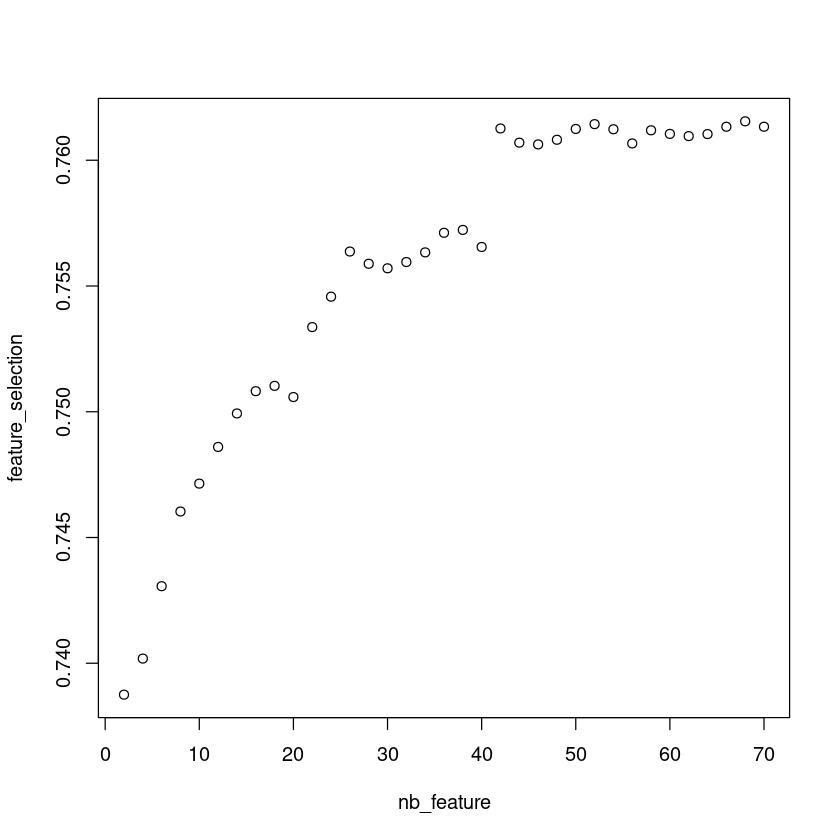

In [14]:
plot(nb_feature,feature_selection)

Les point fesant reculer le f1 score semble etres le 10,14,15,16,20,22,23,28

On vas faire tourner xgboost en enlevant ses feature pour voir si on ne peux pas encore augmenter le f1 score ? 

Si se n'est pas le cas, on s'arretera a 21 car on arrive a un plateaux et il ny a pas d'ameloration sinificative a se moment la 

In [31]:
colnames(data.dummy)[ranking.dummy[one_feature_remove]]

[1] "has_superstructure_rc_engineered"      
 [2] "roof_type.q"                           
 [3] "other_floor_type.x"                    
 [4] "legal_ownership_status.v"              
 [5] "has_superstructure_bamboo"             
 [6] "has_secondary_use_hotel"               
 [7] "has_superstructure_cement_mortar_stone"
 [8] "legal_ownership_status.w"              
 [9] "has_secondary_use_institution"         
[10] "plan_configuration.a"                  
[11] "plan_configuration.o"                  
[12] "foundation_type.h"

In [30]:
length(feature_selection)

[1] 12

In [42]:
diff_feature_selection <- matrix(0, nrow = 35, ncol = 2)
for (i in 1:34){ diff_feature_selection[i,1] <- (feature_selection[i]-feature_selection[i+1])
                 diff_feature_selection[i,2] <- i+1 }
print(diff_feature_selection)

               [,1] [,2]
 [1,] -1.435160e-03    2
 [2,] -2.877947e-03    3
 [3,] -2.970035e-03    4
 [4,] -1.109010e-03    5
 [5,] -1.458158e-03    6
 [6,] -1.331490e-03    7
 [7,] -8.864007e-04    8
 [8,] -2.111063e-04    9
 [9,]  4.451169e-04   10
[10,] -2.781997e-03   11
[11,] -1.208768e-03   12
[12,] -1.795870e-03   13
[13,]  4.873850e-04   14
[14,]  1.803051e-04   15
[15,] -2.493790e-04   16
[16,] -3.837284e-04   17
[17,] -7.790365e-04   18
[18,] -1.150658e-04   19
[19,]  6.792062e-04   20
[20,] -4.712219e-03   21
[21,]  5.641006e-04   22
[22,]  6.907829e-05   23
[23,] -1.842145e-04   24
[24,] -4.297877e-04   25
[25,] -1.917979e-04   26
[26,]  2.033617e-04   27
[27,]  5.640149e-04   28
[28,] -5.218493e-04   29
[29,]  1.419882e-04   30
[30,]  8.828680e-05   31
[31,] -8.065447e-05   32
[32,] -2.915929e-04   33
[33,] -2.148855e-04   34
[34,]  2.148713e-04   35
[35,]  0.000000e+00    0


In [45]:
one_feature_remove <- c(19,20,27,28,29,30,39,40,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70)

In [46]:
set.seed(2)
k = 5
accuracy_vec <- 1:k
#accuracy_matrix_one_feature_remove <- matrix(0, nrow = length(seq(one_feature_remove)), ncol = k)
#idx_bar <-1

#pb1 <- txtProgressBar(min = 1, max = length(one_feature_remove), style = 3)

#for (l in one_feature_remove){
    tic()
    X.dummy.f  <- X.dummy[,ranking.dummy[-one_feature_remove]]
    
    spam_idx <- sample(1:nrow(X.dummy.f))
    max <- ceiling(nrow(X.dummy.f)/k)
    splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 
    
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
    for (i in 1:k){
        X.dummy.f.test <- X.dummy.f[splits[[i]],]
        y.dummy.test <- y.dummy[splits[[i]]]
        X.dummy.f.train <- X.dummy.f[-splits[[i]],]
        y.dummy.train <- y.dummy[-splits[[i]]]
    
        grid_default <- expand.grid(
        nrounds = 100,
        max_depth = 6,
        eta = 0.3,
        gamma = 0,
        colsample_bytree = 1,
        min_child_weight = 1,
        subsample = 1
        )
        
        train_control <- caret::trainControl(
        method = "none",
        verboseIter = FALSE, # no training log
        allowParallel = TRUE, # FALSE for reproducible results 
        summaryFunction = multiClassSummary
        )

        xgb_model <- caret::train(
        x = X.dummy.f.train,
        y = as.factor(y.dummy.train),
        trControl = train_control,
        tuneGrid = grid_default,
        method = "xgbTree",
        verbose = TRUE
        )

        pred <- predict(xgb_model, X.dummy.f.test)
        ll <- length(y.dummy.test)
        cfm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:ll){cfm[pred[j],(y.dummy.test[j]+1)] <- cfm[pred[j],(y.dummy.test[j]+1)]+1}
        TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
        FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
        FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
    }
    mean(accuracy_vec)
 #   setTxtProgressBar(pb1, idx_bar)
  #  print(mean(accuracy_matrix_one_feature_remove[idx_bar,]))
   # idx_bar <- idx_bar +1
    toc()
#

  |                                                                      |   0%[1] 0.7605955
  |==================                                                    |  25%[1] 0.757756
  |===================================                                   |  50%[1] 0.7611327
  |====================================================                  |  75%[1] 0.7612479
  |======================================================================| 100%[1] 0.7595218


[1] 0.7600508

177.615 sec elapsed


In [39]:
set.seed(200)
k = 5
accuracy_vec <- 1:k
#accuracy_matrix_one_feature_remove <- matrix(0, nrow = length(seq(one_feature_remove)), ncol = k)
#idx_bar <-1

#pb1 <- txtProgressBar(min = 1, max = length(one_feature_remove), style = 3)

#for (l in one_feature_remove){
    tic()
    X.dummy.f  <- X.dummy[,ranking.dummy[-one_feature_remove]]
    
    spam_idx <- sample(1:nrow(X.dummy.f))
    max <- ceiling(nrow(X.dummy.f)/k)
    splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 
    
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
    for (i in 1:k){
        X.dummy.f.test <- X.dummy.f[splits[[i]],]
        y.dummy.test <- y.dummy[splits[[i]]]
        X.dummy.f.train <- X.dummy.f[-splits[[i]],]
        y.dummy.train <- y.dummy[-splits[[i]]]
    
        grid_default <- expand.grid(
        nrounds = 100,
        max_depth = 6,
        eta = 0.3,
        gamma = 0,
        colsample_bytree = 1,
        min_child_weight = 1,
        subsample = 1
        )
        
        train_control <- caret::trainControl(
        method = "none",
        verboseIter = FALSE, # no training log
        allowParallel = TRUE, # FALSE for reproducible results 
        summaryFunction = multiClassSummary
        )

        xgb_model <- caret::train(
        x = X.dummy.f.train,
        y = as.factor(y.dummy.train),
        trControl = train_control,
        tuneGrid = grid_default,
        method = "xgbTree",
        verbose = TRUE
        )

        pred <- predict(xgb_model, X.dummy.f.test)
        ll <- length(y.dummy.test)
        cfm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:ll){cfm[pred[j],(y.dummy.test[j]+1)] <- cfm[pred[j],(y.dummy.test[j]+1)]+1}
        TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
        FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
        FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
    }
    mean(accuracy_vec)
 #   setTxtProgressBar(pb1, idx_bar)
  #  print(mean(accuracy_matrix_one_feature_remove[idx_bar,]))
   # idx_bar <- idx_bar +1
    toc()
#

  |                                                                      |   0%[1] 0.759195
  |==================                                                    |  25%[1] 0.7612671
  |===================================                                   |  50%[1] 0.7596362
  |====================================================                  |  75%[1] 0.7629171
  |======================================================================| 100%[1] 0.7593875


[1] 0.7604806

183.027 sec elapsed


In [47]:
two_feature_remove <- c(19,20,27,28,39,40,43,44,45,46,53,54,55,56)

In [48]:
set.seed(3)
k = 5
accuracy_vec <- 1:k
#accuracy_matrix_one_feature_remove <- matrix(0, nrow = length(seq(one_feature_remove)), ncol = k)
#idx_bar <-1

#pb1 <- txtProgressBar(min = 1, max = length(one_feature_remove), style = 3)

#for (l in one_feature_remove){
    tic()
    X.dummy.f  <- X.dummy[,ranking.dummy[-two_feature_remove]]
    
    spam_idx <- sample(1:nrow(X.dummy.f))
    max <- ceiling(nrow(X.dummy.f)/k)
    splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 
    
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
    for (i in 1:k){
        X.dummy.f.test <- X.dummy.f[splits[[i]],]
        y.dummy.test <- y.dummy[splits[[i]]]
        X.dummy.f.train <- X.dummy.f[-splits[[i]],]
        y.dummy.train <- y.dummy[-splits[[i]]]
    
        grid_default <- expand.grid(
        nrounds = 100,
        max_depth = 6,
        eta = 0.3,
        gamma = 0,
        colsample_bytree = 1,
        min_child_weight = 1,
        subsample = 1
        )
        
        train_control <- caret::trainControl(
        method = "none",
        verboseIter = FALSE, # no training log
        allowParallel = TRUE, # FALSE for reproducible results 
        summaryFunction = multiClassSummary
        )

        xgb_model <- caret::train(
        x = X.dummy.f.train,
        y = as.factor(y.dummy.train),
        trControl = train_control,
        tuneGrid = grid_default,
        method = "xgbTree",
        verbose = TRUE
        )

        pred <- predict(xgb_model, X.dummy.f.test)
        ll <- length(y.dummy.test)
        cfm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:ll){cfm[pred[j],(y.dummy.test[j]+1)] <- cfm[pred[j],(y.dummy.test[j]+1)]+1}
        TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
        FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
        FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
    }
    mean(accuracy_vec)
 #   setTxtProgressBar(pb1, idx_bar)
  #  print(mean(accuracy_matrix_one_feature_remove[idx_bar,]))
   # idx_bar <- idx_bar +1
    toc()
#

  |                                                                      |   0%[1] 0.760845
  |==================                                                    |  25%[1] 0.7609793
  |===================================                                   |  50%[1] 0.7640299
  |====================================================                  |  75%[1] 0.7585618
  |======================================================================| 100%[1] 0.763321


[1] 0.7615474

263.271 sec elapsed


In [35]:
set.seed(4)
k = 5
accuracy_vec <- 1:k
#accuracy_matrix_one_feature_remove <- matrix(0, nrow = length(seq(one_feature_remove)), ncol = k)
#idx_bar <-1

#pb1 <- txtProgressBar(min = 1, max = length(one_feature_remove), style = 3)

#for (l in one_feature_remove){
    tic()
    X.dummy.f  <- X.dummy[,ranking.dummy[-two_feature_remove]]
    
    spam_idx <- sample(1:nrow(X.dummy.f))
    max <- ceiling(nrow(X.dummy.f)/k)
    splits <- split(spam_idx, ceiling(seq_along(spam_idx)/max)) 
    
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    
    for (i in 1:k){
        X.dummy.f.test <- X.dummy.f[splits[[i]],]
        y.dummy.test <- y.dummy[splits[[i]]]
        X.dummy.f.train <- X.dummy.f[-splits[[i]],]
        y.dummy.train <- y.dummy[-splits[[i]]]
    
        grid_default <- expand.grid(
        nrounds = 100,
        max_depth = 6,
        eta = 0.3,
        gamma = 0,
        colsample_bytree = 1,
        min_child_weight = 1,
        subsample = 1
        )
        
        train_control <- caret::trainControl(
        method = "none",
        verboseIter = FALSE, # no training log
        allowParallel = TRUE, # FALSE for reproducible results 
        summaryFunction = multiClassSummary
        )

        xgb_model <- caret::train(
        x = X.dummy.f.train,
        y = as.factor(y.dummy.train),
        trControl = train_control,
        tuneGrid = grid_default,
        method = "xgbTree",
        verbose = TRUE
        )

        pred <- predict(xgb_model, X.dummy.f.test)
        ll <- length(y.dummy.test)
        cfm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:ll){cfm[pred[j],(y.dummy.test[j]+1)] <- cfm[pred[j],(y.dummy.test[j]+1)]+1}
        TP <- c(cfm[1,1],cfm[2,2],cfm[3,3])
        FP <- c(cfm[2,1]+cfm[3,1],cfm[1,2]+cfm[3,2],cfm[1,3]+cfm[2,3])
        FN <- c(cfm[1,2]+cfm[1,3],cfm[2,1]+cfm[2,3],cfm[3,1]+cfm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
    
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))   
    
    }
    mean(accuracy_vec)
 #   setTxtProgressBar(pb1, idx_bar)
  #  print(mean(accuracy_matrix_one_feature_remove[idx_bar,]))
   # idx_bar <- idx_bar +1
    toc()
#

  |                                                                      |   0%[1] 0.7584851
  |==================                                                    |  25%[1] 0.7610944
  |===================================                                   |  50%[1] 0.7619769
  |====================================================                  |  75%[1] 0.7623607
  |======================================================================| 100%[1] 0.7620354


[1] 0.7611905

293.378 sec elapsed
